In [1]:
import pandas as pd


In [4]:

import pandas as pd

df = pd.read_csv("prepwise_cleaned_dataset (3).csv")

In [5]:
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.shape

(518596, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518596 entries, 0 to 518595
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoice      518596 non-null  object 
 1   stockcode    518596 non-null  object 
 2   description  515668 non-null  object 
 3   quantity     518596 non-null  int64  
 4   invoicedate  518596 non-null  object 
 5   price        518596 non-null  float64
 6   customer_id  410763 non-null  float64
 7   country      518596 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 31.7+ MB


In [8]:
df.isnull().sum()

invoice             0
stockcode           0
description      2928
quantity            0
invoicedate         0
price               0
customer_id    107833
country             0
dtype: int64

In [9]:
print("Negative quantities:", (df["quantity"] < 0).sum())
print("Negative prices:", (df["price"] < 0).sum())

print("\nNegative quantity examples:")
display(df[df["quantity"] < 0].head(20))

print("\nNegative price examples:")
display(df[df["price"] < 0].head(20))

Negative quantities: 12302
Negative prices: 3

Negative quantity examples:


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom



Negative price examples:


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
177338,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
273025,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
398731,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [10]:
df["quantity"].describe()

count    518596.000000
mean         10.438152
std         108.126593
min       -9600.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: quantity, dtype: float64

In [11]:
# Remove the 3 invalid bad-debt records
df = df[df["price"] >= 0].copy()

# Convert invoice date from text to datetime
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

print(df.shape)
print(df["invoicedate"].min())
print(df["invoicedate"].max())

(518593, 8)
2009-12-01 07:45:00
2010-12-09 20:01:00


In [12]:
df = df[df["price"] >= 0].copy()

In [13]:
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

In [14]:
negative_qty = df[df["quantity"] < 0]

print(negative_qty.shape)
print(negative_qty.head())

(12302, 8)
     invoice stockcode                    description  quantity  \
178  C489449     22087       PAPER BUNTING WHITE LACE       -12   
179  C489449    85206A   CREAM FELT EASTER EGG BASKET        -6   
180  C489449     21895  POTTING SHED SOW 'N' GROW SET        -4   
181  C489449     21896             POTTING SHED TWINE        -6   
182  C489449     22083     PAPER CHAIN KIT RETRO SPOT       -12   

            invoicedate  price  customer_id    country  
178 2009-12-01 10:33:00   2.95      16321.0  Australia  
179 2009-12-01 10:33:00   1.65      16321.0  Australia  
180 2009-12-01 10:33:00   4.25      16321.0  Australia  
181 2009-12-01 10:33:00   2.10      16321.0  Australia  
182 2009-12-01 10:33:00   2.95      16321.0  Australia  


In [17]:
print(negative_qty["invoice"].head(20))

178    C489449
179    C489449
180    C489449
181    C489449
182    C489449
183    C489449
184    C489449
185    C489449
186    C489449
196    C489459
197    C489459
198    C489459
199    C489459
200    C489459
201    C489459
202    C489459
203    C489459
204    C489459
205    C489459
206    C489459
Name: invoice, dtype: object


In [16]:
print(df.columns)

Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country'],
      dtype='object')


In [18]:
print(df.isnull().sum())

invoice             0
stockcode           0
description      2928
quantity            0
invoicedate         0
price               0
customer_id    107830
country             0
dtype: int64


In [19]:
print(df[df["description"].isna()].head(20))

      invoice stockcode description  quantity         invoicedate  price  \
462    489521     21646         NaN       -50 2009-12-01 11:44:00    0.0   
3077   489655     20683         NaN       -44 2009-12-01 17:26:00    0.0   
3124   489659     21350         NaN       230 2009-12-01 17:39:00    0.0   
3687   489781     84292         NaN        17 2009-12-02 11:45:00    0.0   
4233   489806     18010         NaN      -770 2009-12-02 12:42:00    0.0   
4499   489821    85049G         NaN      -240 2009-12-02 13:25:00    0.0   
6299   489882    35751C         NaN        12 2009-12-02 16:22:00    0.0   
6476   489898    79323G         NaN       954 2009-12-03 09:40:00    0.0   
6497   489901     21098         NaN      -200 2009-12-03 09:47:00    0.0   
6502   489903     21166         NaN        48 2009-12-03 09:57:00    0.0   
7123   490015     21982         NaN       467 2009-12-03 12:29:00    0.0   
7124   490016     21982         NaN     -1012 2009-12-03 12:30:00    0.0   
7478   49005

In [20]:
df = df.dropna(subset=["description"]).copy()

print(df.shape)
print(df.isnull().sum())

(515665, 8)
invoice             0
stockcode           0
description         0
quantity            0
invoicedate         0
price               0
customer_id    104902
country             0
dtype: int64


In [22]:
df["customer_id"] = df["customer_id"].fillna("Unknown")
print(df.isnull().sum())

invoice        0
stockcode      0
description    0
quantity       0
invoicedate    0
price          0
customer_id    0
country        0
dtype: int64


In [23]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [24]:
print(df.dtypes)

invoice                object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
price                 float64
customer_id            object
country                object
dtype: object


In [25]:
print("Negative quantities:", (df["quantity"] < 0).sum())
print("Zero quantities:", (df["quantity"] == 0).sum())

print("Zero prices:", (df["price"] == 0).sum())
print("Negative prices:", (df["price"] < 0).sum())

Negative quantities: 10475
Zero quantities: 0
Zero prices: 753
Negative prices: 0


In [26]:
print(df["quantity"].describe())
print()
print(df["price"].describe())

count    515665.000000
mean         10.617775
std          98.548787
min       -9360.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: quantity, dtype: float64

count    515665.000000
mean          5.007790
std          97.403592
min           0.000000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: price, dtype: float64


In [30]:
zero_price = df[df["price"] == 0]

print(zero_price.head(20))

      invoice stockcode                     description  quantity  \
263    489464     21733                    85123a mixed       -96   
283    489463     71477                           short      -240   
284    489467    85123A                     21733 mixed      -192   
3125   489660     35956                            lost     -1043   
3131   489663    35605A                         damages      -117   
4471   489820     21133                 invcd as 84879?      -720   
4607   489825     22076              6 RIBBONS EMPIRE          12   
5833   489861       DOT                  DOTCOM POSTAGE         1   
6477   489899   79323GR                    sold as gold      -954   
6702   489998     48185             DOOR MAT FAIRY CAKE         2   
6832   490007     84347                           21494      -720   
9216   490130     21493                           lost?      -600   
15906  490727         M                          Manual         1   
17226  490765     21450           

In [28]:
print(zero_price["quantity"].describe())
print(zero_price["stockcode"].nunique())
print(zero_price["description"].nunique())

count      753.000000
mean      -165.264276
std        952.040470
min      -9000.000000
25%        -57.000000
50%          1.000000
75%          2.000000
max      10200.000000
Name: quantity, dtype: float64
481
375


In [29]:
print(zero_price["description"].value_counts().head(20))

description
?                                      45
damages                                39
damaged                                38
missing                                24
OWL DOORSTOP                            8
checked                                 8
POLYESTER FILLER PAD 45x45cm            7
PICNIC BASKET WICKER LARGE              7
FLAG OF ST GEORGE CAR FLAG              6
given away                              6
dotcom                                  6
ENAMEL FIRE BUCKET CREAM                5
HEART OF WICKER SMALL                   5
WATERING CAN BLUE ELEPHANT              5
POLYESTER FILLER PAD 40x40cm            5
smashed                                 5
SMALL POPCORN HOLDER                    5
ENAMEL WASH BOWL CREAM                  5
PICNIC BASKET WICKER SMALL              5
AIRLINE BAG VINTAGE WORLD CHAMPION      5
Name: count, dtype: int64


In [31]:
df = df[df["price"] > 0].copy()

print(df.shape)
print(df["price"].min())
print(df["quantity"].min())

(514912, 8)
0.001
-9360


In [32]:
print(df.nlargest(10, "quantity")[
    ["invoice", "stockcode", "description", "quantity", "price"]
])

       invoice stockcode                         description  quantity  price
89849   497946     37410  BLACK AND WHITE PAISLEY FLOWER MUG     19152   0.10
125789  501534     21099         SET/6 STRAWBERRY PAPER CUPS     12960   0.10
125791  501534     21091         SET/6 WOODLAND PAPER PLATES     12960   0.10
125792  501534     21085           SET/6 WOODLAND PAPER CUPS     12744   0.10
125790  501534     21092       SET/6 STRAWBERRY PAPER PLATES     12480   0.10
133513  502269     21984    PACK OF 12 PINK PAISLEY TISSUES      10000   0.25
133514  502269     21982            PACK OF 12 SUKI TISSUES      10000   0.25
133515  502269     21980      PACK OF 12 RED SPOTTY TISSUES      10000   0.25
133516  502269     21981        PACK OF 12 WOODLAND TISSUES      10000   0.25
92646   498152     85220     SMALL FAIRY CAKE FRIDGE MAGNETS      9456   0.30


In [33]:
print(df.nsmallest(10, "quantity")[
    ["invoice", "stockcode", "description", "quantity", "price"]
])

        invoice stockcode                          description  quantity  \
500620  C536757     84347  ROTATING SILVER ANGELS T-LIGHT HLDR     -9360   
355456  C524235     21088         SET/6 FRUIT SALAD PAPER CUPS     -7128   
355457  C524235     21096      SET/6 FRUIT SALAD  PAPER PLATES     -7008   
355417  C524235     16047              POP ART PEN CASE & PENS     -5184   
355423  C524235     37340        MULTICOLOUR SPRING FLOWER MUG     -4992   
355440  C524235     85110   BLACK SILVER FLOWER T-LIGHT HOLDER     -4752   
355445  C524235     16046              TEATIME PEN CASE & PENS     -4608   
355441  C524235    85160A         WHITE BIRD GARDEN DESIGN MUG     -4320   
355461  C524235    85184D       S/4 BLUE ROUND DECOUPAGE BOXES     -3936   
355447  C524235    16162L                    THE KING GIFT BAG     -3744   

        price  
500620   0.03  
355456   0.08  
355457   0.13  
355417   0.08  
355423   0.10  
355440   0.07  
355445   0.08  
355441   0.13  
355461   0.42  
355

In [34]:
df["is_cancelled"] = df["invoice"].astype(str).str.startswith("C")

In [35]:
print(df["is_cancelled"].value_counts())

is_cancelled
False    504730
True      10182
Name: count, dtype: int64


In [36]:
df["revenue"] = df["quantity"] * df["price"]

print(df[["quantity", "price", "revenue"]].head())
print()
print(df["revenue"].describe())

   quantity  price  revenue
0        12   6.95     83.4
1        12   6.75     81.0
2        12   6.75     81.0
3        48   2.10    100.8
4        24   1.25     30.0

count    514912.000000
mean         18.726166
std         118.031066
min      -25111.090000
25%           3.800000
50%          10.080000
75%          17.700000
max       25111.090000
Name: revenue, dtype: float64


In [37]:
print((df["revenue"] < 0).sum())
print(df.loc[df["revenue"] < 0, "is_cancelled"].value_counts())

10181
is_cancelled
True    10181
Name: count, dtype: int64


In [38]:
print("Net revenue:", df["revenue"].sum())

Net revenue: 9642327.583999999


In [39]:
print("Cancellation revenue:", df.loc[df["is_cancelled"], "revenue"].sum())
print("Sales revenue:", df.loc[~df["is_cancelled"], "revenue"].sum())

Cancellation revenue: -629435.08
Sales revenue: 10271762.663999999


In [40]:
print(
    df.loc[df["is_cancelled"], "quantity"]
      .gt(0)
      .sum()
)

1


In [41]:
df.loc[
    (df["is_cancelled"]) & (df["quantity"] > 0),
    ["invoice", "stockcode", "description", "quantity", "price", "revenue"]
]

,invoice,stockcode,description,quantity,price,revenue
75972,C496350,M,Manual,1,373.57,373.57


In [42]:
df.loc[
    (df["is_cancelled"]) & (df["quantity"] > 0),
    ["invoice", "stockcode", "description", "quantity", "price", "revenue"]
]

,invoice,stockcode,description,quantity,price,revenue
75972,C496350,M,Manual,1,373.57,373.57


In [43]:
df.loc[
    (df["is_cancelled"]) & (df["quantity"] > 0),
    "description"
].value_counts()

description
Manual    1
Name: count, dtype: int64

In [44]:
print("Unique invoices:", df["invoice"].nunique())
print("Unique products:", df["stockcode"].nunique())
print("Unique countries:", df["country"].nunique())

Unique invoices: 25543
Unique products: 4265
Unique countries: 40


In [45]:
print("Unknown customers:", (df["customer_id"] == "Unknown").sum())
print("Percentage:", (df["customer_id"] == "Unknown").mean() * 100)

Unknown customers: 104180
Percentage: 20.232583431732024


In [46]:
print(
    pd.crosstab(
        df["customer_id"].eq("Unknown"),
        df["is_cancelled"],
        normalize="index"
    ) * 100
)

is_cancelled      False     True 
customer_id                      
False         97.610120  2.389880
True          99.648685  0.351315


In [47]:
print("=" * 60)
print("MLPILOT — SUBJECT MODEL DATA CLEANING SUMMARY")
print("=" * 60)

print("\n1. DATASET SHAPE")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

print("\n2. COLUMNS")
print(list(df.columns))

print("\n3. MISSING VALUES")
print(df.isnull().sum())

print("\n4. DUPLICATES")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n5. DATA TYPES")
print(df.dtypes)

print("\n6. PRICE VALIDATION")
print(f"Negative prices: {(df['price'] < 0).sum()}")
print(f"Zero prices: {(df['price'] == 0).sum()}")
print(f"Minimum price: {df['price'].min()}")
print(f"Maximum price: {df['price'].max()}")

print("\n7. QUANTITY VALIDATION")
print(f"Negative quantities: {(df['quantity'] < 0).sum()}")
print(f"Zero quantities: {(df['quantity'] == 0).sum()}")
print(f"Minimum quantity: {df['quantity'].min()}")
print(f"Maximum quantity: {df['quantity'].max()}")

print("\n8. CANCELLATIONS / RETURNS")
print(f"Cancellation/adjustment rows: {df['is_cancelled'].sum():,}")
print(f"Negative-revenue rows: {(df['revenue'] < 0).sum():,}")
print(f"Positive-quantity C invoices: "
      f"{((df['is_cancelled']) & (df['quantity'] > 0)).sum()}")

print("\n9. CUSTOMER IDs")
unknown = (df["customer_id"] == "Unknown").sum()
print(f"Unknown customer IDs: {unknown:,}")
print(f"Unknown customer percentage: {unknown / len(df) * 100:.2f}%")

print("\n10. REVENUE")
print(f"Normal sales revenue: "
      f"{df.loc[~df['is_cancelled'], 'revenue'].sum():,.2f}")
print(f"Cancellation/return revenue: "
      f"{df.loc[df['is_cancelled'], 'revenue'].sum():,.2f}")
print(f"Net revenue: {df['revenue'].sum():,.2f}")

print("\n11. DATASET CARDINALITY")
print(f"Unique invoices: {df['invoice'].nunique():,}")
print(f"Unique products: {df['stockcode'].nunique():,}")
print(f"Unique countries: {df['country'].nunique():,}")

print("\n12. FINAL STATUS")
print("✓ Negative-price rows removed")
print("✓ Missing descriptions removed")
print("✓ Missing customer IDs replaced with 'Unknown'")
print("✓ Duplicate rows checked")
print("✓ Data types validated")
print("✓ Zero-price records removed")
print("✓ Negative quantities retained as legitimate returns/cancellations")
print("✓ Extreme quantities retained after investigation")
print("✓ Cancellation flag created")
print("✓ Revenue feature created")
print("✓ Dataset ready for EDA / subject-model development")

print("=" * 60)

MLPILOT — SUBJECT MODEL DATA CLEANING SUMMARY

1. DATASET SHAPE
Rows: 514,912
Columns: 10

2. COLUMNS
['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country', 'is_cancelled', 'revenue']

3. MISSING VALUES
invoice         0
stockcode       0
description     0
quantity        0
invoicedate     0
price           0
customer_id     0
country         0
is_cancelled    0
revenue         0
dtype: int64

4. DUPLICATES
Duplicate rows: 0

5. DATA TYPES
invoice                 object
stockcode               object
description             object
quantity                 int64
invoicedate     datetime64[ns]
price                  float64
customer_id             object
country                 object
is_cancelled              bool
revenue                float64
dtype: object

6. PRICE VALIDATION
Negative prices: 0
Zero prices: 0
Minimum price: 0.001
Maximum price: 25111.09

7. QUANTITY VALIDATION
Negative quantities: 10181
Zero quantities: 0
Minimum quantit

In [49]:
# Keep only genuine sales
sales_df = df[df["quantity"] > 0].copy()

# Extract the date (remove time)
sales_df["date"] = sales_df["invoicedate"].dt.date

# Aggregate total quantity sold per day
daily_demand = (
    sales_df.groupby("date")["quantity"]
    .sum()
    .reset_index()
)

# Rename the target column
daily_demand.rename(
    columns={"quantity": "daily_demand"},
    inplace=True
)

daily_demand.head()

,date,daily_demand
0,2009-12-01,26098
1,2009-12-02,31804
2,2009-12-03,49221
3,2009-12-04,21210
4,2009-12-05,5119


In [54]:
daily_demand.shape


(307, 2)

In [53]:
daily_demand.tail()

,date,daily_demand
302,2010-12-05,16242
303,2010-12-06,21619
304,2010-12-07,25180
305,2010-12-08,23041
306,2010-12-09,19898


In [55]:
print("Start date:", daily_demand["date"].min())
print("End date:", daily_demand["date"].max())
print("Number of recorded days:", len(daily_demand))

Start date: 2009-12-01
End date: 2010-12-09
Number of recorded days: 307


In [56]:
# Convert date column back to datetime
daily_demand["date"] = pd.to_datetime(daily_demand["date"])

# Create every calendar day in the date range
all_dates = pd.date_range(
    start=daily_demand["date"].min(),
    end=daily_demand["date"].max(),
    freq="D"
)

# Find dates with no recorded transactions
missing_dates = all_dates.difference(daily_demand["date"])

print("Total calendar days:", len(all_dates))
print("Missing dates:", len(missing_dates))

missing_dates[:20]

Total calendar days: 374
Missing dates: 67


DatetimeIndex(['2009-12-12', '2009-12-19', '2009-12-24', '2009-12-25',
               '2009-12-26', '2009-12-27', '2009-12-28', '2009-12-29',
               '2009-12-30', '2009-12-31', '2010-01-01', '2010-01-02',
               '2010-01-03', '2010-01-09', '2010-01-16', '2010-01-23',
               '2010-01-30', '2010-02-06', '2010-02-13', '2010-02-20'],
              dtype='datetime64[ns]', freq=None)

In [57]:
missing_df = pd.DataFrame({
    "date": missing_dates
})

missing_df["day_name"] = missing_df["date"].dt.day_name()

missing_df["day_name"].value_counts()

day_name
Saturday     52
Monday        5
Friday        3
Sunday        3
Thursday      2
Tuesday       1
Wednesday     1
Name: count, dtype: int64

In [58]:
missing_df.sort_values("date").head(30)

,date,day_name
0,2009-12-12,Saturday
1,2009-12-19,Saturday
2,2009-12-24,Thursday
3,2009-12-25,Friday
4,2009-12-26,Saturday
5,2009-12-27,Sunday
6,2009-12-28,Monday
7,2009-12-29,Tuesday
8,2009-12-30,Wednesday
9,2009-12-31,Thursday


In [59]:
missing_df["day_name"].value_counts()

day_name
Saturday     52
Monday        5
Friday        3
Sunday        3
Thursday      2
Tuesday       1
Wednesday     1
Name: count, dtype: int64

In [60]:
non_saturday_missing = missing_df[
    missing_df["day_name"] != "Saturday"
]

non_saturday_missing.sort_values("date")

,date,day_name
2,2009-12-24,Thursday
3,2009-12-25,Friday
5,2009-12-27,Sunday
6,2009-12-28,Monday
7,2009-12-29,Tuesday
8,2009-12-30,Wednesday
9,2009-12-31,Thursday
10,2010-01-01,Friday
12,2010-01-03,Sunday
25,2010-04-02,Friday


In [61]:
# Number of transactions on the first and last day
sales_df["date"] = pd.to_datetime(sales_df["invoicedate"]).dt.normalize()

first_day = sales_df["date"].min()
last_day = sales_df["date"].max()

print("First day:", first_day)
print("Last day:", last_day)

print("\nFirst day transactions:")
print(sales_df[sales_df["date"] == first_day].shape[0])

print("\nLast day transactions:")
print(sales_df[sales_df["date"] == last_day].shape[0])

print("\nLast day latest transaction time:")
print(
    sales_df[sales_df["date"] == last_day]["invoicedate"].max()
)

First day: 2009-12-01 00:00:00
Last day: 2010-12-09 00:00:00

First day transactions:
3068

Last day transactions:
2765

Last day latest transaction time:
2010-12-09 20:01:00


In [62]:
# Ensure date is datetime
daily_demand["date"] = pd.to_datetime(daily_demand["date"])

# Create a continuous daily date range
all_dates = pd.date_range(
    start=daily_demand["date"].min(),
    end=daily_demand["date"].max(),
    freq="D"
)

# Create complete daily time series
daily_demand = (
    daily_demand
    .set_index("date")
    .reindex(all_dates, fill_value=0)
    .rename_axis("date")
    .reset_index()
)

daily_demand.head(15)

,date,daily_demand
0,2009-12-01,26098
1,2009-12-02,31804
2,2009-12-03,49221
3,2009-12-04,21210
4,2009-12-05,5119
5,2009-12-06,11533
6,2009-12-07,17955
7,2009-12-08,23143
8,2009-12-09,17840
9,2009-12-10,23579


In [63]:
print("Shape:", daily_demand.shape)

print("\nMissing values:")
print(daily_demand.isnull().sum())

print("\nZero-demand days:")
print((daily_demand["daily_demand"] == 0).sum())

Shape: (374, 2)

Missing values:
date            0
daily_demand    0
dtype: int64

Zero-demand days:
67


In [64]:
daily_demand["daily_demand"].describe()

count       374.000000
mean      15542.641711
std       13999.787196
min           0.000000
25%        8639.250000
50%       13886.500000
75%       21011.000000
max      125489.000000
Name: daily_demand, dtype: float64

In [65]:
daily_demand.sort_values(
    "daily_demand",
    ascending=False
).head(10)

,date,daily_demand
300,2010-09-27,125489
251,2010-08-09,100224
76,2010-02-15,96425
106,2010-03-17,78859
51,2010-01-21,72900
338,2010-11-04,60269
112,2010-03-23,54452
2,2009-12-03,49221
13,2009-12-14,45332
311,2010-10-08,41441


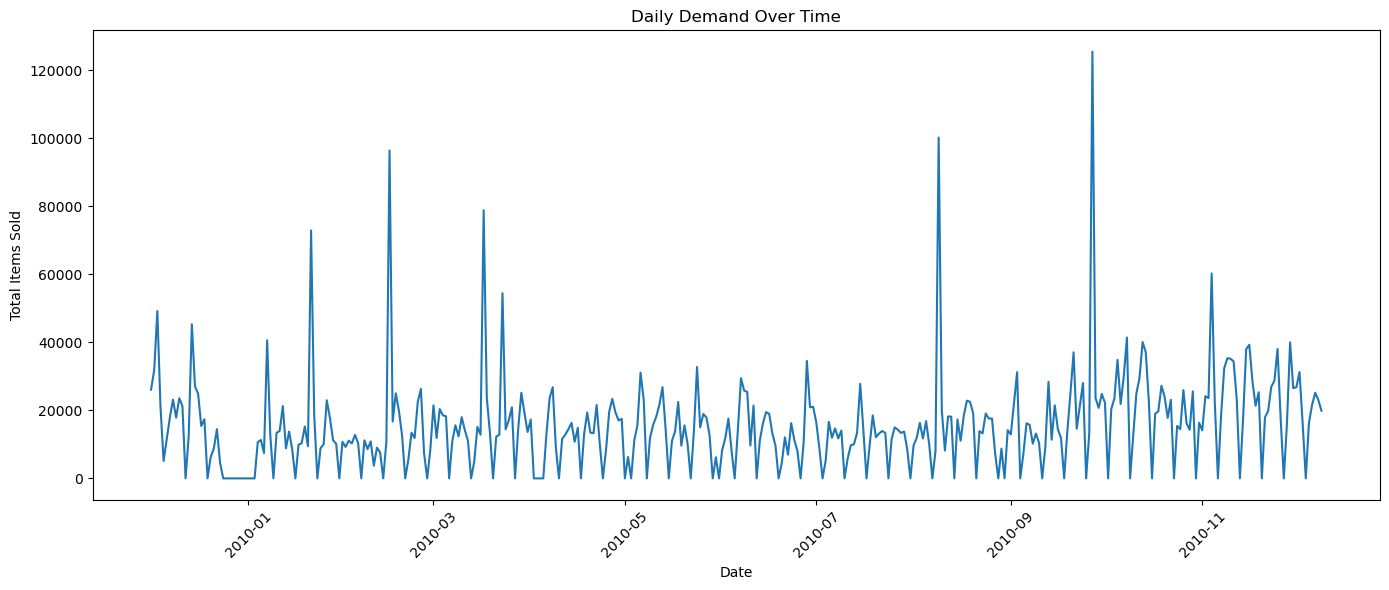

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["daily_demand"]
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Items Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [67]:
top_days = daily_demand.nlargest(3, "daily_demand")

top_days

,date,daily_demand
300,2010-09-27,125489
251,2010-08-09,100224
76,2010-02-15,96425


In [68]:
for date in top_days["date"]:
    
    print("\n" + "=" * 60)
    print("DATE:", date.date())
    print("=" * 60)
    
    day_data = sales_df[
        sales_df["invoicedate"].dt.normalize() == date
    ]
    
    print("Transactions:", len(day_data))
    print("Total Quantity:", day_data["quantity"].sum())
    
    display(
        day_data.nlargest(10, "quantity")[
            ["invoice", "stockcode", "description", "quantity", "price"]
        ]
    )


DATE: 2010-09-27
Transactions: 2252
Total Quantity: 125489


,invoice,stockcode,description,quantity,price
354554,524174,21088,SET/6 FRUIT SALAD PAPER CUPS,7128,0.08
354553,524174,21096,SET/6 FRUIT SALAD PAPER PLATES,7008,0.13
354564,524174,16047,POP ART PEN CASE & PENS,5184,0.08
354545,524174,37340,MULTICOLOUR SPRING FLOWER MUG,4992,0.10
354528,524174,85110,BLACK SILVER FLOWER T-LIGHT HOLDER,4752,0.07
354565,524174,16046,TEATIME PEN CASE & PENS,4608,0.08
354527,524174,85160A,WHITE BIRD GARDEN DESIGN MUG,4320,0.13
354525,524174,85184D,S/4 BLUE ROUND DECOUPAGE BOXES,3936,0.42
354562,524174,16162L,THE KING GIFT BAG,3744,0.05
354547,524174,21392,RED POLKADOT PUDDING BOWL,3648,0.13



DATE: 2010-08-09
Transactions: 875
Total Quantity: 100224


,invoice,stockcode,description,quantity,price
295412,518505,21088,SET/6 FRUIT SALAD PAPER CUPS,7128,0.08
295411,518505,21096,SET/6 FRUIT SALAD PAPER PLATES,7008,0.13
295423,518505,16047,POP ART PEN CASE & PENS,5184,0.08
295403,518505,37340,MULTICOLOUR SPRING FLOWER MUG,4992,0.10
295386,518505,85110,BLACK SILVER FLOWER T-LIGHT HOLDER,4752,0.07
295424,518505,16046,TEATIME PEN CASE & PENS,4608,0.08
295385,518505,85160A,WHITE BIRD GARDEN DESIGN MUG,4320,0.13
295383,518505,85184D,S/4 BLUE ROUND DECOUPAGE BOXES,3936,0.42
295421,518505,16162L,THE KING GIFT BAG,3744,0.05
295405,518505,21392,RED SPOTTY PUDDING BOWL,3648,0.13



DATE: 2010-02-15
Transactions: 874
Total Quantity: 96425


,invoice,stockcode,description,quantity,price
89849,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10
89858,497946,47503E,ASS FLORAL PRINT SCISSORS,6696,0.15
89874,497946,20760,GARDEN PATH POCKET BOOK,4320,0.10
89863,497946,20729,RED SPOTTY CANDY BAG,4200,0.15
89856,497946,47504E,ENGLISH ROSE SCISSORS,4176,0.15
89867,497946,20778,GARDEN PATH NOTEBOOK,3360,0.15
89870,497946,20775,DAISY NOTEBOOK,3360,0.15
89850,497946,85198,ASSORTED FARMYARD ANIMALS IN BUCKET,3312,0.30
89868,497946,20777,CHRYSANTHEMUM NOTEBOOK,3200,0.15
89871,497946,20774,GREEN FERN NOTEBOOK,3200,0.15


In [69]:
for date in top_days["date"]:
    
    day_data = sales_df[
        sales_df["invoicedate"].dt.normalize() == date
    ].copy()

    invoice_totals = (
        day_data.groupby("invoice")["quantity"]
        .sum()
        .sort_values(ascending=False)
    )

    total = day_data["quantity"].sum()
    largest = invoice_totals.iloc[0]

    print("\n" + "=" * 60)
    print("DATE:", date.date())
    print("Total demand:", total)
    print("Largest invoice:", invoice_totals.index[0])
    print("Largest invoice quantity:", largest)
    print(
        "Largest invoice contribution:",
        round((largest / total) * 100, 2),
        "%"
    )


DATE: 2010-09-27
Total demand: 125489
Largest invoice: 524174
Largest invoice quantity: 87167
Largest invoice contribution: 69.46 %

DATE: 2010-08-09
Total demand: 100224
Largest invoice: 518505
Largest invoice quantity: 87167
Largest invoice contribution: 86.97 %

DATE: 2010-02-15
Total demand: 96425
Largest invoice: 497946
Largest invoice quantity: 83774
Largest invoice contribution: 86.88 %


In [70]:
daily_demand["day_name"] = daily_demand["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = (
    daily_demand
    .groupby("day_name")["daily_demand"]
    .mean()
    .reindex(weekday_order)
)

weekday_demand

day_name
Monday       22288.962264
Tuesday      19538.018519
Wednesday    18972.814815
Thursday     21559.148148
Friday       15182.735849
Saturday        96.584906
Sunday       10906.603774
Name: daily_demand, dtype: float64

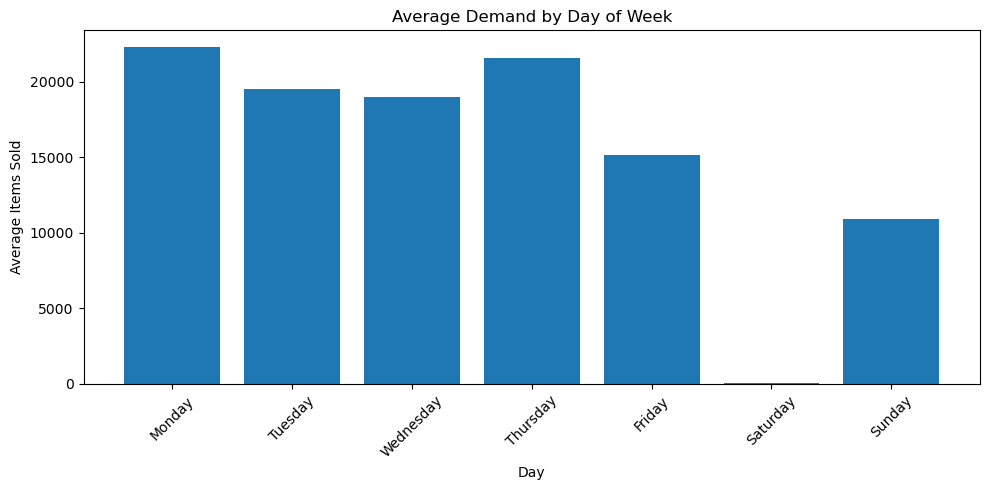

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_demand.index,
    weekday_demand.values
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Items Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [72]:
weekday_median = (
    daily_demand
    .groupby("day_name")["daily_demand"]
    .median()
    .reindex(weekday_order)
)

print("Median demand by weekday:")
print(weekday_median)

Median demand by weekday:
day_name
Monday       15713.0
Tuesday      18275.0
Wednesday    17838.5
Thursday     17851.5
Friday       14072.0
Saturday         0.0
Sunday       11120.0
Name: daily_demand, dtype: float64


In [73]:
weekday_comparison = pd.DataFrame({
    "mean": weekday_demand,
    "median": weekday_median
})

weekday_comparison

,mean,median
day_name,,
Monday,22288.962264,15713.0
Tuesday,19538.018519,18275.0
Wednesday,18972.814815,17838.5
Thursday,21559.148148,17851.5
Friday,15182.735849,14072.0
Saturday,96.584906,0.0
Sunday,10906.603774,11120.0


In [74]:
daily_demand["month"] = daily_demand["date"].dt.month
daily_demand["month_name"] = daily_demand["date"].dt.month_name()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_demand = (
    daily_demand
    .groupby("month_name")["daily_demand"]
    .mean()
    .reindex(month_order)
)

monthly_demand

month_name
January      12602.322581
February     13638.571429
March        16968.580645
April        12223.500000
May          12769.935484
June         13560.666667
July         10899.838710
August       15238.064516
September    19462.133333
October      19999.870968
November     24172.033333
December     15142.025000
Name: daily_demand, dtype: float64

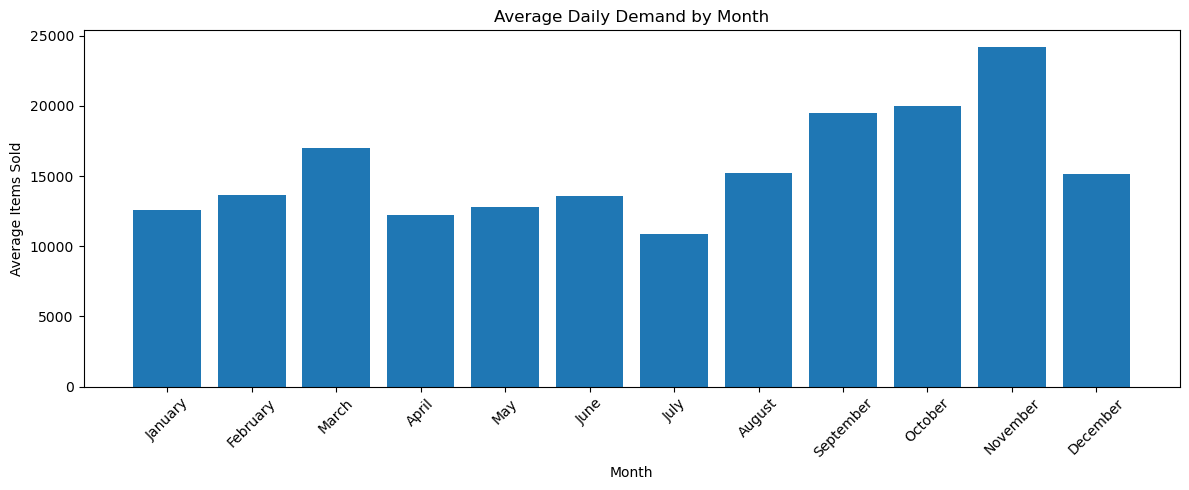

In [75]:
plt.figure(figsize=(12, 5))

plt.bar(
    monthly_demand.index,
    monthly_demand.values
)

plt.title("Average Daily Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Items Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

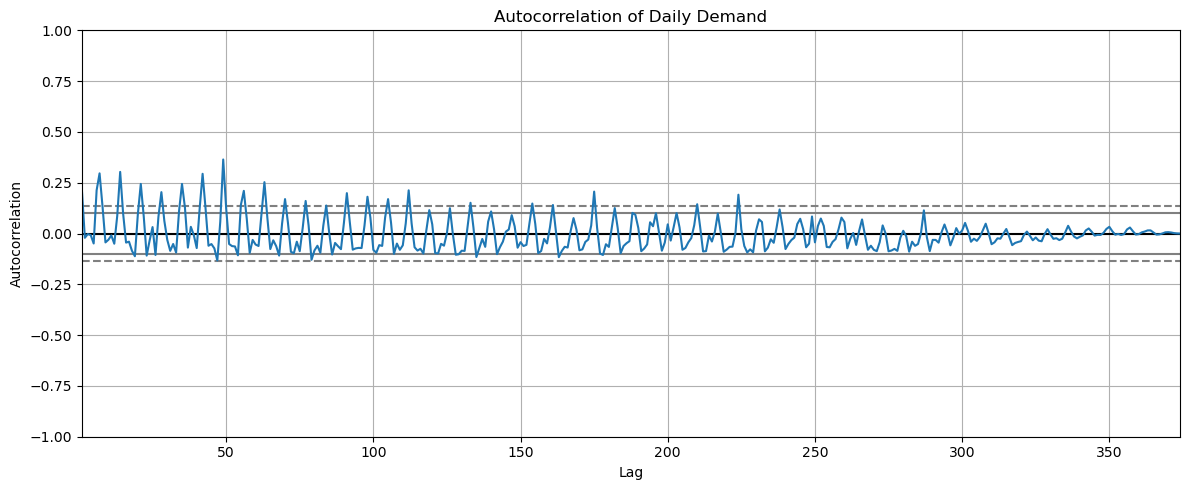

In [76]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

autocorrelation_plot(daily_demand["daily_demand"])

plt.title("Autocorrelation of Daily Demand")
plt.tight_layout()

plt.show()

In [77]:
for lag in [1, 2, 3, 7, 14, 30]:
    correlation = daily_demand["daily_demand"].autocorr(lag=lag)
    print(f"Lag {lag}: {correlation:.4f}")

Lag 1: 0.2143
Lag 2: -0.0212
Lag 3: -0.0028
Lag 7: 0.3005
Lag 14: 0.3134
Lag 30: -0.0332


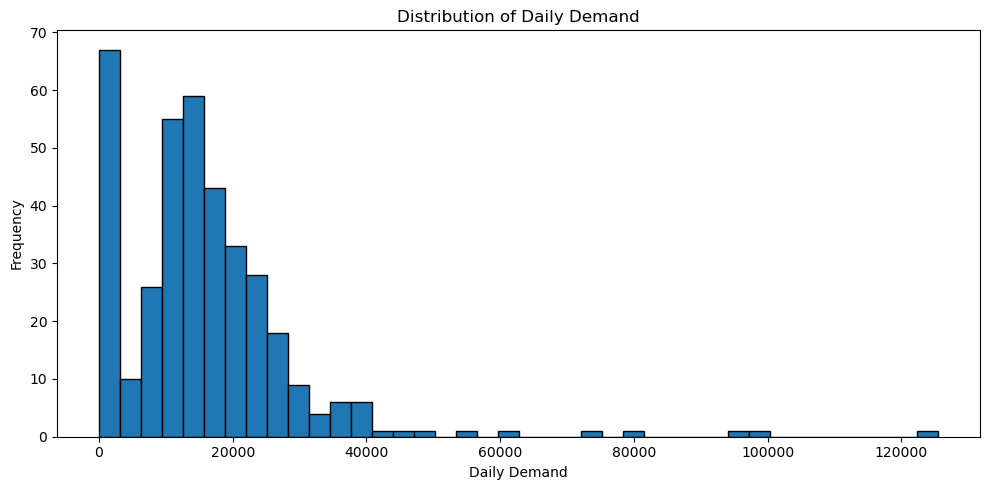

In [78]:
plt.figure(figsize=(10, 5))

plt.hist(
    daily_demand["daily_demand"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Daily Demand")
plt.xlabel("Daily Demand")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [79]:
print(
    "Skewness:",
    daily_demand["daily_demand"].skew()
)

Skewness: 3.0248693479148656


In [80]:
df_features = daily_demand.copy()

df_features.head()

,date,daily_demand,day_name,month,month_name
0,2009-12-01,26098,Tuesday,12,December
1,2009-12-02,31804,Wednesday,12,December
2,2009-12-03,49221,Thursday,12,December
3,2009-12-04,21210,Friday,12,December
4,2009-12-05,5119,Saturday,12,December


In [81]:
df_features["day_of_week"] = df_features["date"].dt.dayofweek

df_features["month"] = df_features["date"].dt.month

df_features["day_of_month"] = df_features["date"].dt.day

df_features["week_of_year"] = (
    df_features["date"].dt.isocalendar().week.astype(int)
)

df_features.head()

,date,daily_demand,day_name,month,month_name,day_of_week,day_of_month,week_of_year
0,2009-12-01,26098,Tuesday,12,December,1,1,49
1,2009-12-02,31804,Wednesday,12,December,2,2,49
2,2009-12-03,49221,Thursday,12,December,3,3,49
3,2009-12-04,21210,Friday,12,December,4,4,49
4,2009-12-05,5119,Saturday,12,December,5,5,49


In [82]:
df_features["lag_1"] = df_features["daily_demand"].shift(1)

df_features["lag_7"] = df_features["daily_demand"].shift(7)

df_features["lag_14"] = df_features["daily_demand"].shift(14)

In [83]:
df_features["rolling_mean_7"] = (
    df_features["daily_demand"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

df_features["rolling_mean_14"] = (
    df_features["daily_demand"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

In [84]:
df_features.isnull().sum()

date                0
daily_demand        0
day_name            0
month               0
month_name          0
day_of_week         0
day_of_month        0
week_of_year        0
lag_1               1
lag_7               7
lag_14             14
rolling_mean_7      7
rolling_mean_14    14
dtype: int64

In [85]:
df_features = df_features.dropna()

print(df_features.shape)

(360, 13)


In [86]:
df_features.head()

,date,daily_demand,day_name,month,month_name,day_of_week,day_of_month,week_of_year,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
14,2009-12-15,27064,Tuesday,12,December,1,15,51,45332.0,23143.0,26098.0,20525.571429,21901.357143
15,2009-12-16,24891,Wednesday,12,December,2,16,51,27064.0,17840.0,31804.0,21085.714286,21970.357143
16,2009-12-17,15413,Thursday,12,December,3,17,51,24891.0,23579.0,49221.0,22093.000000,21476.571429
17,2009-12-18,17402,Friday,12,December,4,18,51,15413.0,21268.0,21210.0,20926.428571,19061.714286
18,2009-12-19,0,Saturday,12,December,5,19,51,17402.0,0.0,5119.0,20374.142857,18789.714286


In [87]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 360 entries, 14 to 373
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             360 non-null    datetime64[ns]
 1   daily_demand     360 non-null    int64         
 2   day_name         360 non-null    object        
 3   month            360 non-null    int32         
 4   month_name       360 non-null    object        
 5   day_of_week      360 non-null    int32         
 6   day_of_month     360 non-null    int32         
 7   week_of_year     360 non-null    int64         
 8   lag_1            360 non-null    float64       
 9   lag_7            360 non-null    float64       
 10  lag_14           360 non-null    float64       
 11  rolling_mean_7   360 non-null    float64       
 12  rolling_mean_14  360 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int32(3), int64(2), object(2)
memory usage: 35.2+ KB


In [88]:
df_features.shape

(360, 13)

In [89]:
df_features.head()

,date,daily_demand,day_name,month,month_name,day_of_week,day_of_month,week_of_year,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
14,2009-12-15,27064,Tuesday,12,December,1,15,51,45332.0,23143.0,26098.0,20525.571429,21901.357143
15,2009-12-16,24891,Wednesday,12,December,2,16,51,27064.0,17840.0,31804.0,21085.714286,21970.357143
16,2009-12-17,15413,Thursday,12,December,3,17,51,24891.0,23579.0,49221.0,22093.000000,21476.571429
17,2009-12-18,17402,Friday,12,December,4,18,51,15413.0,21268.0,21210.0,20926.428571,19061.714286
18,2009-12-19,0,Saturday,12,December,5,19,51,17402.0,0.0,5119.0,20374.142857,18789.714286


In [90]:
# Features we will use

features = [
    "day_of_week",
    "month",
    "day_of_month",
    "week_of_year",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14"
]

target = "daily_demand"


# 80% training data
train_size = int(len(df_features) * 0.8)


train = df_features.iloc[:train_size]

test = df_features.iloc[train_size:]


print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

Training data shape: (288, 13)
Testing data shape: (72, 13)

Training period:
2009-12-15 00:00:00 to 2010-09-28 00:00:00

Testing period:
2010-09-29 00:00:00 to 2010-12-09 00:00:00


In [91]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [92]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (288, 9)
X_test: (72, 9)
y_train: (288,)
y_test: (72,)


In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Naive prediction:
# Predict today's demand using yesterday's demand

naive_predictions = test["lag_1"]

# MAE
naive_mae = mean_absolute_error(
    y_test,
    naive_predictions
)

# RMSE
naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

print("Naive Baseline Results")
print("----------------------")
print(f"MAE: {naive_mae:.2f}")
print(f"RMSE: {naive_rmse:.2f}")

Naive Baseline Results
----------------------
MAE: 11690.22
RMSE: 14932.73


In [94]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [95]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest Results")
print("---------------------")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")

Random Forest Results
---------------------
MAE: 7713.01
RMSE: 10365.14


In [96]:
results = pd.DataFrame({
    "date": test["date"].values,
    "actual": y_test.values,
    "predicted": rf_predictions,
})

results["absolute_error"] = (
    results["actual"] - results["predicted"]
).abs()

results.head(10)

,date,actual,predicted,absolute_error
0,2010-09-29,20736,23272.337061,2536.337061
1,2010-09-30,24834,22284.300973,2549.699027
2,2010-10-01,22213,19164.747356,3048.252644
3,2010-10-02,0,35.263889,35.263889
4,2010-10-03,20343,7174.317386,13168.682614
5,2010-10-04,23529,26789.329502,3260.329502
6,2010-10-05,34855,30201.191151,4653.808849
7,2010-10-06,21884,22421.815428,537.815428
8,2010-10-07,30072,23519.938544,6552.061456
9,2010-10-08,41441,25454.846388,15986.153612


In [97]:
results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,date,actual,predicted,absolute_error
36,2010-11-04,60269,20213.996250,40055.003750
22,2010-10-21,17798,40619.636521,22821.636521
54,2010-11-22,19775,42226.452439,22451.452439
28,2010-10-27,16197,34096.107488,17899.107488
29,2010-10-28,14298,31637.009896,17339.009896
14,2010-10-13,40097,23273.548372,16823.451628
9,2010-10-08,41441,25454.846388,15986.153612
62,2010-11-30,26532,41670.657946,15138.657946
48,2010-11-16,39307,24786.324627,14520.675373
47,2010-11-15,37969,23972.375126,13996.624874


In [98]:
worst_dates = results.nlargest(
    3,
    "absolute_error"
)["date"].tolist()

worst_dates

[Timestamp('2010-11-04 00:00:00'),
 Timestamp('2010-10-21 00:00:00'),
 Timestamp('2010-11-22 00:00:00')]

In [99]:
for date in worst_dates:
    
    day_data = df[
        df["invoicedate"].dt.date == date.date()
    ]
    
    print("=" * 60)
    print("DATE:", date)
    print("Transactions:", len(day_data))
    print("Total Demand:", day_data["quantity"].sum())
    
    invoice_demand = (
        day_data.groupby("invoice")["quantity"]
        .sum()
        .sort_values(ascending=False)
    )
    
    print("\nTop 5 invoices by quantity:")
    print(invoice_demand.head())

DATE: 2010-11-04 00:00:00
Transactions: 3616
Total Demand: 60031

Top 5 invoices by quantity:
invoice
530715    15696
530714     9640
530799     3556
530846     1606
530648     1430
Name: quantity, dtype: int64
DATE: 2010-10-21 00:00:00
Transactions: 2137
Total Demand: 17656

Top 5 invoices by quantity:
invoice
528159    1865
528331     966
528304     754
528271     579
528307     570
Name: quantity, dtype: int64
DATE: 2010-11-22 00:00:00
Transactions: 3244
Total Demand: 19712

Top 5 invoices by quantity:
invoice
534364    1104
534289     975
534389     964
534395     960
534319     933
Name: quantity, dtype: int64


In [100]:
worst_cases = df_features[
    df_features["date"].isin(worst_dates)
]

worst_cases[
    [
        "date",
        "daily_demand",
        "day_of_week",
        "month",
        "lag_1",
        "lag_7",
        "lag_14",
        "rolling_mean_7",
        "rolling_mean_14"
    ]
]

,date,daily_demand,day_of_week,month,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
324,2010-10-21,17798,3,10,24039.0,37123.0,30072.0,21351.285714,23423.357143
338,2010-11-04,60269,3,11,23637.0,14298.0,17798.0,16879.714286,16512.500000
356,2010-11-22,19775,0,11,17985.0,37969.0,32397.0,24355.571429,24881.428571


In [101]:
# Recalculate daily demand directly from df

check_daily_demand = (
    df.groupby(df["invoicedate"].dt.date)["quantity"]
    .sum()
    .reset_index()
)

check_daily_demand.columns = ["date", "recalculated_demand"]

check_daily_demand["date"] = pd.to_datetime(
    check_daily_demand["date"]
)

# Compare with our existing daily_demand dataset

comparison_check = daily_demand.merge(
    check_daily_demand,
    on="date",
    how="left"
)

comparison_check["difference"] = (
    comparison_check["daily_demand"]
    - comparison_check["recalculated_demand"]
)

# Show dates where values don't match

comparison_check[
    comparison_check["difference"] != 0
]

,date,daily_demand,day_name,month,month_name,recalculated_demand,difference
0,2009-12-01,26098,Tuesday,12,December,25468.0,630.0
1,2009-12-02,31804,Wednesday,12,December,31538.0,266.0
2,2009-12-03,49221,Thursday,12,December,46819.0,2402.0
3,2009-12-04,21210,Friday,12,December,21104.0,106.0
5,2009-12-06,11533,Sunday,12,December,11471.0,62.0
...,...,...,...,...,...,...,...
369,2010-12-05,16242,Sunday,12,December,16186.0,56.0
370,2010-12-06,21619,Monday,12,December,21320.0,299.0
371,2010-12-07,25180,Tuesday,12,December,25076.0,104.0
372,2010-12-08,23041,Wednesday,12,December,22743.0,298.0


In [102]:
comparison_check["difference"].describe()

count      307.000000
mean       694.752443
std       5075.780877
min          0.000000
25%         53.000000
50%        140.000000
75%        330.000000
max      87493.000000
Name: difference, dtype: float64

In [103]:
(comparison_check["difference"] != 0).sum()

np.int64(371)

In [104]:
comparison_check.nlargest(
    10,
    "difference"
)[
    [
        "date",
        "daily_demand",
        "recalculated_demand",
        "difference"
    ]
]

,date,daily_demand,recalculated_demand,difference
301,2010-09-28,23634,-63859.0,87493.0
366,2010-12-02,31264,20977.0,10287.0
163,2010-05-13,26817,17786.0,9031.0
209,2010-06-28,34536,27122.0,7414.0
7,2009-12-08,23143,19290.0,3853.0
331,2010-10-28,14298,11030.0,3268.0
343,2010-11-09,35361,32202.0,3159.0
188,2010-06-07,29457,26693.0,2764.0
300,2010-09-27,125489,122733.0,2756.0
350,2010-11-16,39307,36599.0,2708.0


In [105]:
date_to_check = pd.Timestamp("2010-09-28")

day_data = df[
    df["invoicedate"].dt.normalize() == date_to_check
]

print("Total rows:", len(day_data))
print("Positive quantity sum:", day_data.loc[
    day_data["quantity"] > 0, "quantity"
].sum())

print("Negative quantity sum:", day_data.loc[
    day_data["quantity"] < 0, "quantity"
].sum())

print("Net quantity:", day_data["quantity"].sum())

Total rows: 2835
Positive quantity sum: 23634
Negative quantity sum: -87493
Net quantity: -63859


In [106]:
day_data.sort_values(
    "quantity"
).head(20)[
    [
        "invoice",
        "stockcode",
        "description",
        "quantity",
        "price",
        "is_cancelled"
    ]
]

,invoice,stockcode,description,quantity,price,is_cancelled
355456,C524235,21088,SET/6 FRUIT SALAD PAPER CUPS,-7128,0.08,True
355457,C524235,21096,SET/6 FRUIT SALAD PAPER PLATES,-7008,0.13,True
355417,C524235,16047,POP ART PEN CASE & PENS,-5184,0.08,True
355423,C524235,37340,MULTICOLOUR SPRING FLOWER MUG,-4992,0.10,True
355440,C524235,85110,BLACK SILVER FLOWER T-LIGHT HOLDER,-4752,0.07,True
355445,C524235,16046,TEATIME PEN CASE & PENS,-4608,0.08,True
355441,C524235,85160A,WHITE BIRD GARDEN DESIGN MUG,-4320,0.13,True
355461,C524235,85184D,S/4 BLUE ROUND DECOUPAGE BOXES,-3936,0.42,True
355447,C524235,16162L,THE KING GIFT BAG,-3744,0.05,True
355421,C524235,21392,RED POLKADOT PUDDING BOWL,-3648,0.13,True


In [107]:
# Recalculate demand using ONLY positive quantities

positive_demand_check = (
    df[df["quantity"] > 0]
    .groupby(df.loc[df["quantity"] > 0, "invoicedate"].dt.normalize())["quantity"]
    .sum()
    .reset_index()
)

positive_demand_check.columns = [
    "date",
    "positive_demand"
]

# Compare with our existing daily_demand

positive_comparison = daily_demand.merge(
    positive_demand_check,
    on="date",
    how="left"
)

positive_comparison["difference"] = (
    positive_comparison["daily_demand"]
    - positive_comparison["positive_demand"]
)

print(
    "Dates with differences:",
    (positive_comparison["difference"] != 0).sum()
)

print("\nDifference summary:")
print(
    positive_comparison["difference"].describe()
)

Dates with differences: 67

Difference summary:
count    307.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: difference, dtype: float64


In [108]:
# Check whether the 67 differences are simply missing dates / NaN values

positive_comparison[positive_comparison["difference"].isna()].head(10)

,date,daily_demand,day_name,month,month_name,positive_demand,difference
11,2009-12-12,0,Saturday,12,December,NaN,NaN
18,2009-12-19,0,Saturday,12,December,NaN,NaN
23,2009-12-24,0,Thursday,12,December,NaN,NaN
24,2009-12-25,0,Friday,12,December,NaN,NaN
25,2009-12-26,0,Saturday,12,December,NaN,NaN
26,2009-12-27,0,Sunday,12,December,NaN,NaN
27,2009-12-28,0,Monday,12,December,NaN,NaN
28,2009-12-29,0,Tuesday,12,December,NaN,NaN
29,2009-12-30,0,Wednesday,12,December,NaN,NaN
30,2009-12-31,0,Thursday,12,December,NaN,NaN


In [109]:
print("NaN values in positive_demand:",
      positive_comparison["positive_demand"].isna().sum())

print("Zero-demand days in daily_demand:",
      (daily_demand["daily_demand"] == 0).sum())

NaN values in positive_demand: 67
Zero-demand days in daily_demand: 67


In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual demand
y_actual = test["daily_demand"]

# Predict using demand from 7 days ago
y_pred_lag7 = test["lag_7"]

# Evaluation
mae_lag7 = mean_absolute_error(y_actual, y_pred_lag7)

rmse_lag7 = np.sqrt(
    mean_squared_error(y_actual, y_pred_lag7)
)

print("Lag-7 Seasonal Baseline Results")
print("--------------------------------")
print(f"MAE: {mae_lag7:.2f}")
print(f"RMSE: {rmse_lag7:.2f}")

Lag-7 Seasonal Baseline Results
--------------------------------
MAE: 8044.19
RMSE: 15901.73


In [111]:
import xgboost

print(xgboost.__version__)

3.2.0


In [112]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create the model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

print("XGBoost Results")
print("----------------")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")

XGBoost Results
----------------
MAE: 10059.94
RMSE: 13769.41


In [113]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create the model
gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gbr_model.fit(X_train, y_train)

# Predict
y_pred_gbr = gbr_model.predict(X_test)

# Evaluate
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

rmse_gbr = np.sqrt(
    mean_squared_error(y_test, y_pred_gbr)
)

print("Gradient Boosting Results")
print("--------------------------")
print(f"MAE: {mae_gbr:.2f}")
print(f"RMSE: {rmse_gbr:.2f}")

Gradient Boosting Results
--------------------------
MAE: 9125.60
RMSE: 13073.20


In [114]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Different configurations to test
configs = [
    {
        "n_estimators": 100,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    
    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_split": 5,
        "min_samples_leaf": 2
    },
    
    {
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_split": 5,
        "min_samples_leaf": 2
    },
    
    {
        "n_estimators": 500,
        "max_depth": 8,
        "min_samples_split": 10,
        "min_samples_leaf": 3
    }
]

results_rf = []

for i, config in enumerate(configs, start=1):
    
    model = RandomForestRegressor(
        **config,
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    predictions = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    results_rf.append({
        "Configuration": i,
        "MAE": mae,
        "RMSE": rmse,
        **config
    })


results_rf_df = pd.DataFrame(results_rf)

# Sort by MAE
results_rf_df = results_rf_df.sort_values("MAE")

results_rf_df

,Configuration,MAE,RMSE,n_estimators,max_depth,min_samples_split,min_samples_leaf
3,4,6704.944980,9099.360522,500,8.0,10,3
1,2,7537.606886,10052.635728,200,10.0,5,2
2,3,7695.406263,10354.560347,300,15.0,5,2
0,1,8654.282083,11473.350238,100,NaN,2,1


In [115]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter combinations to explore
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": [1.0, "sqrt"]
}

# Base model
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train ONLY on training data
random_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(-random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 1.0, 'max_depth': 5}

Best Cross-Validation MAE:
5891.6500017476865


In [116]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create the final model using the best parameters
final_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

# Train on the complete training dataset
final_rf_model.fit(X_train, y_train)

# Predict on the untouched test set
final_predictions = final_rf_model.predict(X_test)

# Evaluate
final_mae = mean_absolute_error(y_test, final_predictions)

final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)

print("Final Random Forest Results")
print("---------------------------")
print(f"MAE: {final_mae:.2f}")
print(f"RMSE: {final_rmse:.2f}")

Final Random Forest Results
---------------------------
MAE: 7286.39
RMSE: 9947.92


In [117]:
# Create a dataframe to analyze predictions

final_results = pd.DataFrame({
    "date": test["date"].values,
    "actual": y_test.values,
    "predicted": final_predictions
})

# Calculate errors
final_results["error"] = (
    final_results["actual"] - final_results["predicted"]
)

final_results["absolute_error"] = (
    final_results["error"].abs()
)

final_results.head(10)

,date,actual,predicted,error,absolute_error
0,2010-09-29,20736,22690.571672,-1954.571672,1954.571672
1,2010-09-30,24834,21632.011333,3201.988667,3201.988667
2,2010-10-01,22213,19269.001797,2943.998203,2943.998203
3,2010-10-02,0,89.983889,-89.983889,89.983889
4,2010-10-03,20343,7087.183060,13255.816940,13255.816940
5,2010-10-04,23529,24480.362163,-951.362163,951.362163
6,2010-10-05,34855,28592.495059,6262.504941,6262.504941
7,2010-10-06,21884,21403.281310,480.718690,480.718690
8,2010-10-07,30072,22225.279314,7846.720686,7846.720686
9,2010-10-08,41441,22513.619059,18927.380941,18927.380941


In [118]:
final_results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,date,actual,predicted,error,absolute_error
36,2010-11-04,60269,19644.266761,40624.733239,40624.733239
29,2010-10-28,14298,33257.763443,-18959.763443,18959.763443
9,2010-10-08,41441,22513.619059,18927.380941,18927.380941
28,2010-10-27,16197,34559.424812,-18362.424812,18362.424812
54,2010-11-22,19775,38056.050941,-18281.050941,18281.050941
14,2010-10-13,40097,21889.425829,18207.574171,18207.574171
22,2010-10-21,17798,35070.438644,-17272.438644,17272.438644
48,2010-11-16,39307,22360.324579,16946.675421,16946.675421
47,2010-11-15,37969,22503.936627,15465.063373,15465.063373
15,2010-10-14,37123,22259.913529,14863.086471,14863.086471


In [119]:
# Get the 10 worst prediction dates
worst_dates = worst_predictions["date"]

# Select those dates from our feature dataset
worst_features = df_features[
    df_features["date"].isin(worst_dates)
][
    [
        "date",
        "daily_demand",
        "day_of_week",
        "month",
        "lag_1",
        "lag_7",
        "lag_14",
        "rolling_mean_7",
        "rolling_mean_14"
    ]
]

worst_features.sort_values("date")

NameError: name 'worst_predictions' is not defined

In [120]:
# Get the 10 worst predictions again

worst_predictions = final_results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

worst_predictions

,date,actual,predicted,error,absolute_error
36,2010-11-04,60269,19644.266761,40624.733239,40624.733239
29,2010-10-28,14298,33257.763443,-18959.763443,18959.763443
9,2010-10-08,41441,22513.619059,18927.380941,18927.380941
28,2010-10-27,16197,34559.424812,-18362.424812,18362.424812
54,2010-11-22,19775,38056.050941,-18281.050941,18281.050941
14,2010-10-13,40097,21889.425829,18207.574171,18207.574171
22,2010-10-21,17798,35070.438644,-17272.438644,17272.438644
48,2010-11-16,39307,22360.324579,16946.675421,16946.675421
47,2010-11-15,37969,22503.936627,15465.063373,15465.063373
15,2010-10-14,37123,22259.913529,14863.086471,14863.086471


In [121]:
# Get the dates of the 10 worst predictions
worst_dates = worst_predictions["date"]

# Inspect features for those dates
worst_features = df_features[
    df_features["date"].isin(worst_dates)
][
    [
        "date",
        "daily_demand",
        "day_of_week",
        "month",
        "lag_1",
        "lag_7",
        "lag_14",
        "rolling_mean_7",
        "rolling_mean_14"
    ]
]

worst_features.sort_values("date")

,date,daily_demand,day_of_week,month,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
311,2010-10-08,41441,4,10,30072.0,22213.0,28035.0,21842.285714,27786.357143
316,2010-10-13,40097,2,10,29531.0,21884.0,20736.0,22893.571429,21911.785714
317,2010-10-14,37123,3,10,40097.0,30072.0,24834.0,25495.428571,23294.714286
324,2010-10-21,17798,3,10,24039.0,37123.0,30072.0,21351.285714,23423.357143
330,2010-10-27,16197,2,10,25974.0,24039.0,40097.0,17265.571429,20455.428571
331,2010-10-28,14298,3,10,16197.0,17798.0,37123.0,16145.285714,18748.285714
338,2010-11-04,60269,3,11,23637.0,14298.0,17798.0,16879.714286,16512.500000
349,2010-11-15,37969,0,11,17295.0,32397.0,14127.0,25407.285714,24351.928571
350,2010-11-16,39307,1,11,37969.0,35361.0,24166.0,26203.285714,26054.928571
356,2010-11-22,19775,0,11,17985.0,37969.0,32397.0,24355.571429,24881.428571


In [122]:
# Get feature importance from the final Random Forest model

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": final_rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
0,day_of_week,0.384150
4,lag_1,0.176215
6,lag_14,0.114776
7,rolling_mean_7,0.095808
5,lag_7,0.070316
2,day_of_month,0.057388
3,week_of_year,0.050460
8,rolling_mean_14,0.043116
1,month,0.007770


In [123]:
reduced_features = [
    "day_of_week",
    "day_of_month",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7"
]

X_train_reduced = train[reduced_features]
X_test_reduced = test[reduced_features]

print("Training shape:", X_train_reduced.shape)
print("Testing shape:", X_test_reduced.shape)

Training shape: (288, 6)
Testing shape: (72, 6)


In [124]:
reduced_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

reduced_rf_model.fit(X_train_reduced, y_train)

reduced_predictions = reduced_rf_model.predict(X_test_reduced)

In [125]:
reduced_mae = mean_absolute_error(
    y_test,
    reduced_predictions
)

reduced_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        reduced_predictions
    )
)

print("Reduced Feature Random Forest Results")
print("-------------------------------------")
print(f"MAE: {reduced_mae:.2f}")
print(f"RMSE: {reduced_rmse:.2f}")

Reduced Feature Random Forest Results
-------------------------------------
MAE: 7824.75
RMSE: 10674.37


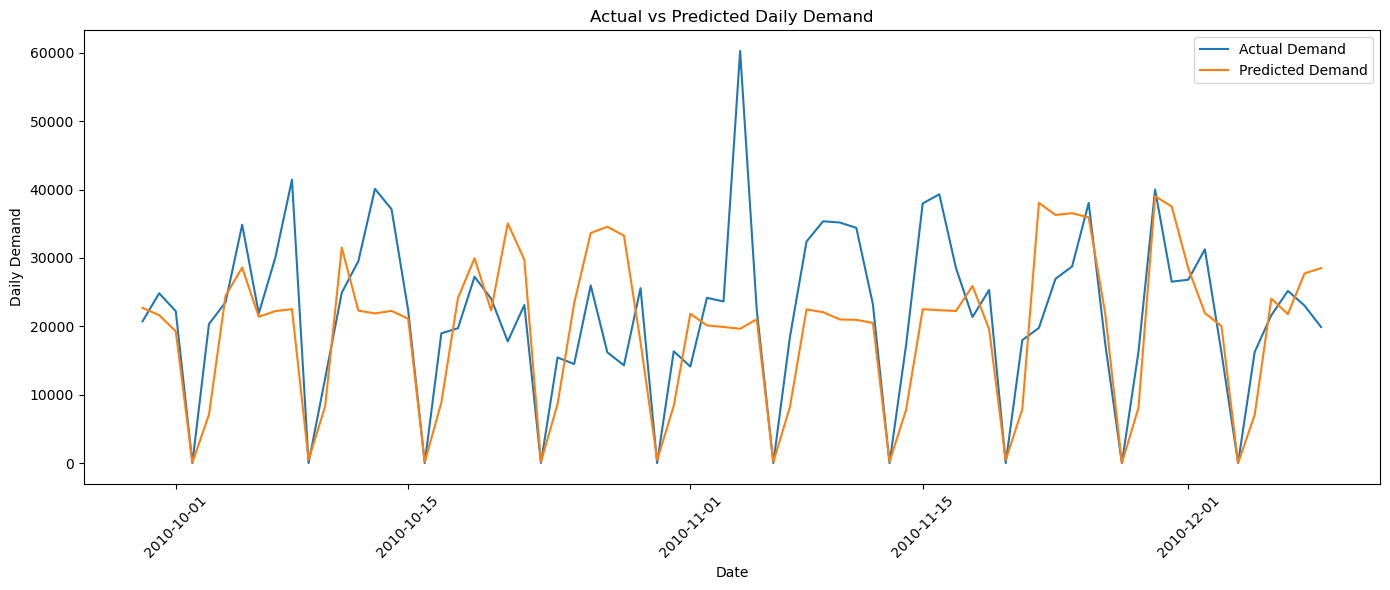

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    final_results["date"],
    final_results["actual"],
    label="Actual Demand"
)

plt.plot(
    final_results["date"],
    final_results["predicted"],
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Daily Demand")
plt.xlabel("Date")
plt.ylabel("Daily Demand")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

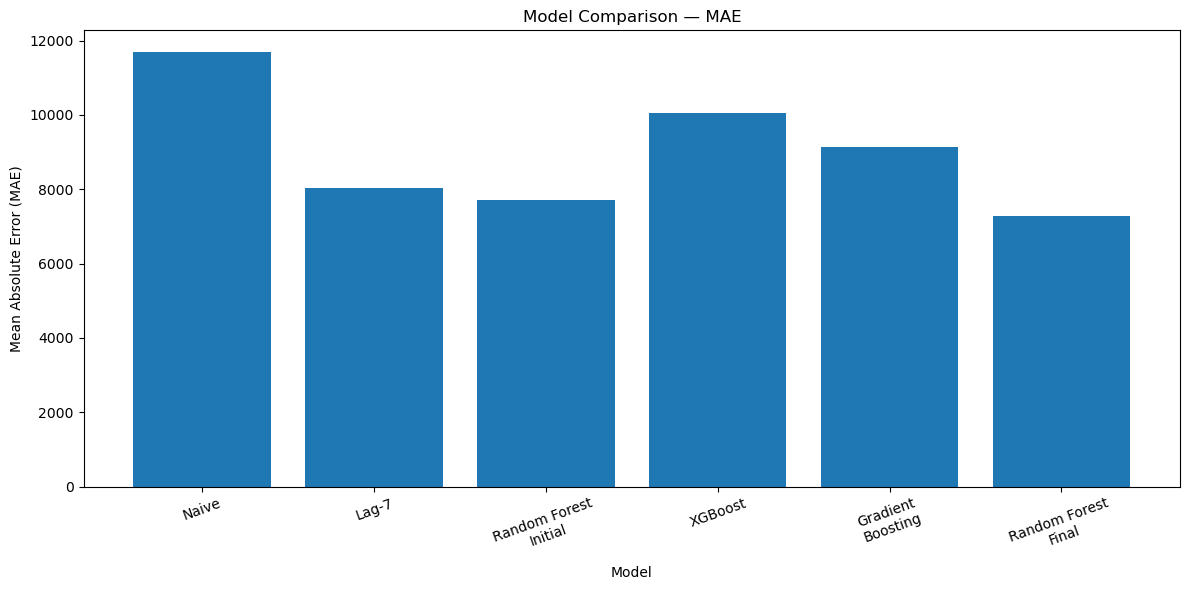

In [127]:
model_names = [
    "Naive",
    "Lag-7",
    "Random Forest\nInitial",
    "XGBoost",
    "Gradient\nBoosting",
    "Random Forest\nFinal"
]

mae_scores = [
    11690.22,
    8044.19,
    7713.01,
    10059.94,
    9125.60,
    7286.39
]

plt.figure(figsize=(12, 6))

plt.bar(model_names, mae_scores)

plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [128]:
import joblib

# Save the trained Random Forest model
joblib.dump(
    final_rf_model,
    "final_demand_forecasting_rf.joblib"
)

# Save the feature names
joblib.dump(
    features,
    "demand_forecasting_features.joblib"
)

print("Model saved successfully!")
print("Feature list saved successfully!")

Model saved successfully!
Feature list saved successfully!


In [129]:
print("""
============================================================
MLPILOT — DEMAND FORECASTING SUBJECT MODEL
FINAL EXPERIMENT SUMMARY
============================================================

1. PROBLEM
Predict daily product demand (total quantity sold) using
historical transaction data.

------------------------------------------------------------

2. DATASET
Original transaction dataset cleaned using PrepWise
and additional subject-model-specific validation.

Final cleaned transaction dataset:
Rows: 514,912
Columns: 10

Date range:
2009-12-01 to 2010-12-09

------------------------------------------------------------

3. TARGET VARIABLE

daily_demand

Definition:
Net daily quantity demand after aggregating transaction
quantities by date.

Missing calendar dates were added and assigned a demand
of 0 because no transactions occurred on those dates.

------------------------------------------------------------

4. FEATURES

Calendar Features:
- day_of_week
- month
- day_of_month
- week_of_year

Historical Features:
- lag_1
- lag_7
- lag_14
- rolling_mean_7
- rolling_mean_14

Total Features: 9

------------------------------------------------------------

5. TRAIN / TEST SPLIT

Training samples: 288
Testing samples: 72

Training period:
2009-12-15 to 2010-09-28

Testing period:
2010-09-29 to 2010-12-09

Chronological split used.
No random shuffling was performed.

------------------------------------------------------------

6. MODELS TESTED

Naive Baseline
MAE: 11690.22
RMSE: 14932.73

Lag-7 Seasonal Baseline
MAE: 8044.19
RMSE: 15901.73

Random Forest (Initial)
MAE: 7713.01
RMSE: 10365.14

XGBoost
MAE: 10059.94
RMSE: 13769.41

Gradient Boosting
MAE: 9125.60
RMSE: 13073.20

------------------------------------------------------------

7. HYPERPARAMETER TUNING

Method:
RandomizedSearchCV

Cross-validation:
TimeSeriesSplit (5 folds)

Best Parameters:

n_estimators: 300
max_depth: 5
min_samples_split: 5
min_samples_leaf: 3
max_features: 1.0

Best Cross-Validation MAE:
5891.65

------------------------------------------------------------

8. FINAL MODEL

Algorithm:
Random Forest Regressor

Final Test Results:

MAE: 7286.39
RMSE: 9947.92

The test set was kept separate during hyperparameter tuning.

------------------------------------------------------------

9. ERROR ANALYSIS

Largest errors occurred during sudden changes in demand.

Examples included:
- Unexpected demand spikes
- Sudden demand drops following high-demand periods

The model struggled to predict events not represented
by historical or calendar features.

Potential missing external factors:
- Bulk orders
- Promotions
- Holidays
- Customer-specific events

------------------------------------------------------------

10. FEATURE IMPORTANCE

Most important feature:

day_of_week: 0.3842

Other important features:
- lag_1
- lag_14
- rolling_mean_7
- lag_7

Month had low individual importance, but feature ablation
showed that removing low-importance features reduced
overall model performance.

------------------------------------------------------------

11. FEATURE ABLATION

Full Feature Model:
MAE: 7286.39
RMSE: 9947.92

Reduced Feature Model:
MAE: 7824.75
RMSE: 10674.37

Decision:
Keep all 9 features.

------------------------------------------------------------

12. FINAL CONCLUSION

The tuned Random Forest model achieved the best overall
performance among the tested models.

The model successfully captures calendar effects and
historical demand patterns but struggles with sudden,
unpredictable demand changes.

Final Model:
Tuned Random Forest Regressor

Final MAE: 7286.39
Final RMSE: 9947.92

============================================================
""")


MLPILOT — DEMAND FORECASTING SUBJECT MODEL
FINAL EXPERIMENT SUMMARY

1. PROBLEM
Predict daily product demand (total quantity sold) using
historical transaction data.

------------------------------------------------------------

2. DATASET
Original transaction dataset cleaned using PrepWise
and additional subject-model-specific validation.

Final cleaned transaction dataset:
Rows: 514,912
Columns: 10

Date range:
2009-12-01 to 2010-12-09

------------------------------------------------------------

3. TARGET VARIABLE

daily_demand

Definition:
Net daily quantity demand after aggregating transaction
quantities by date.

Missing calendar dates were added and assigned a demand
of 0 because no transactions occurred on those dates.

------------------------------------------------------------

4. FEATURES

Calendar Features:
- day_of_week
- month
- day_of_month
- week_of_year

Historical Features:
- lag_1
- lag_7
- lag_14
- rolling_mean_7
- rolling_mean_14

Total Features: 9

------------

In [130]:
# Create a date column

df["date"] = df["invoicedate"].dt.normalize()


# Keep only positive quantities
positive_transactions = df[df["quantity"] > 0].copy()


# Aggregate positive quantity by day
positive_daily_demand = (
    positive_transactions
    .groupby("date")["quantity"]
    .sum()
    .reset_index()
)

positive_daily_demand.columns = [
    "date",
    "daily_demand"
]


positive_daily_demand.head()

,date,daily_demand
0,2009-12-01,26098
1,2009-12-02,31804
2,2009-12-03,49221
3,2009-12-04,21210
4,2009-12-05,5119


In [131]:
# Create the complete date range

all_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)


# Set date as index and reindex

positive_daily_demand = (
    positive_daily_demand
    .set_index("date")
    .reindex(all_dates, fill_value=0)
    .rename_axis("date")
    .reset_index()
)


positive_daily_demand.head()

,date,daily_demand
0,2009-12-01,26098
1,2009-12-02,31804
2,2009-12-03,49221
3,2009-12-04,21210
4,2009-12-05,5119


In [132]:
print("Shape:", positive_daily_demand.shape)

print("\nMissing values:")
print(positive_daily_demand.isnull().sum())

print("\nZero-demand days:")
print(
    (positive_daily_demand["daily_demand"] == 0).sum()
)

print("\nDemand statistics:")
print(
    positive_daily_demand["daily_demand"].describe()
)

Shape: (374, 2)

Missing values:
date            0
daily_demand    0
dtype: int64

Zero-demand days:
67

Demand statistics:
count       374.000000
mean      15542.641711
std       13999.787196
min           0.000000
25%        8639.250000
50%       13886.500000
75%       21011.000000
max      125489.000000
Name: daily_demand, dtype: float64


In [133]:
comparison = daily_demand.merge(
    positive_daily_demand,
    on="date",
    suffixes=("_net", "_positive")
)

comparison["difference"] = (
    comparison["daily_demand_positive"]
    - comparison["daily_demand_net"]
)

comparison.sort_values(
    "difference",
    ascending=False
).head(10)

,date,daily_demand_net,day_name,month,month_name,daily_demand_positive,difference
0,2009-12-01,26098,Tuesday,12,December,26098,0
246,2010-08-04,11740,Wednesday,8,August,11740,0
255,2010-08-13,18159,Friday,8,August,18159,0
254,2010-08-12,18216,Thursday,8,August,18216,0
253,2010-08-11,8197,Wednesday,8,August,8197,0
252,2010-08-10,20053,Tuesday,8,August,20053,0
251,2010-08-09,100224,Monday,8,August,100224,0
250,2010-08-08,8120,Sunday,8,August,8120,0
249,2010-08-07,0,Saturday,8,August,0,0
248,2010-08-06,9923,Friday,8,August,9923,0


In [135]:
# Show only dates where net demand and positive demand differ

different_days = comparison[
    comparison["difference"] != 0
]

print("Number of days with differences:", len(different_days))

different_days.sort_values(
    "difference",
    ascending=False
).head(20)

Number of days with differences: 0


,date,daily_demand_net,day_name,month,month_name,daily_demand_positive,difference


In [136]:
# Create date column
df["date"] = df["invoicedate"].dt.normalize()


# 1. NET DAILY DEMAND
net_demand = (
    df.groupby("date")["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "net_demand"})
)


# 2. POSITIVE DAILY DEMAND
positive_demand = (
    df[df["quantity"] > 0]
    .groupby("date")["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "positive_demand"})
)


# 3. Merge them
target_comparison = net_demand.merge(
    positive_demand,
    on="date",
    how="outer"
)


# Fill dates with no positive sales
target_comparison["positive_demand"] = (
    target_comparison["positive_demand"].fillna(0)
)


# Calculate difference
target_comparison["difference"] = (
    target_comparison["positive_demand"]
    - target_comparison["net_demand"]
)


# Show dates where they differ
different_days = target_comparison[
    target_comparison["difference"] != 0
]

print("Number of different days:", len(different_days))

print("\nLargest differences:")
print(
    different_days
    .sort_values("difference", ascending=False)
    .head(10)
)

Number of different days: 304

Largest differences:
          date  net_demand  positive_demand  difference
244 2010-09-28      -63859            23634       87493
300 2010-12-02       20977            31264       10287
128 2010-05-13       17786            26817        9031
166 2010-06-28       27122            34536        7414
7   2009-12-08       19290            23143        3853
270 2010-10-28       11030            14298        3268
280 2010-11-09       32202            35361        3159
148 2010-06-07       26693            29457        2764
243 2010-09-27      122733           125489        2756
286 2010-11-16       36599            39307        2708


In [137]:
target_comparison[
    target_comparison["date"] == "2010-09-28"
]

,date,net_demand,positive_demand,difference
244,2010-09-28,-63859,23634,87493


In [138]:
# Create a continuous date range
all_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)


# Reindex positive demand to include every calendar day
daily_demand_positive = (
    positive_demand
    .set_index("date")
    .reindex(all_dates, fill_value=0)
    .rename_axis("date")
    .reset_index()
)


daily_demand_positive.columns = [
    "date",
    "daily_demand"
]


print("Shape:", daily_demand_positive.shape)

print("\nDate range:")
print(
    daily_demand_positive["date"].min(),
    "to",
    daily_demand_positive["date"].max()
)

print("\nMissing values:")
print(daily_demand_positive.isnull().sum())

print("\nZero-demand days:")
print(
    (daily_demand_positive["daily_demand"] == 0).sum()
)

print("\nDemand statistics:")
print(
    daily_demand_positive["daily_demand"].describe()
)

Shape: (374, 2)

Date range:
2009-12-01 00:00:00 to 2010-12-09 00:00:00

Missing values:
date            0
daily_demand    0
dtype: int64

Zero-demand days:
67

Demand statistics:
count       374.000000
mean      15542.641711
std       13999.787196
min           0.000000
25%        8639.250000
50%       13886.500000
75%       21011.000000
max      125489.000000
Name: daily_demand, dtype: float64


In [139]:
daily_demand_positive[
    daily_demand_positive["date"] == "2010-09-28"
]

,date,daily_demand
301,2010-09-28,23634


In [140]:
daily_demand_positive.sort_values(
    "daily_demand",
    ascending=False
).head(10)

,date,daily_demand
300,2010-09-27,125489
251,2010-08-09,100224
76,2010-02-15,96425
106,2010-03-17,78859
51,2010-01-21,72900
338,2010-11-04,60269
112,2010-03-23,54452
2,2009-12-03,49221
13,2009-12-14,45332
311,2010-10-08,41441


In [141]:
print(df_features[["date", "daily_demand"]].head())

print("\n2010-09-28:")
print(
    df_features[
        df_features["date"] == "2010-09-28"
    ][["date", "daily_demand"]]
)

         date  daily_demand
14 2009-12-15         27064
15 2009-12-16         24891
16 2009-12-17         15413
17 2009-12-18         17402
18 2009-12-19             0

2010-09-28:
          date  daily_demand
301 2010-09-28         23634
